Running grid search for Random Forest...
Fitting 5 folds for each of 144 candidates, totalling 720 fits
Random Forest - Best params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}
Random Forest - CV Best Score: 0.9948
Random Forest - Precision: 0.9984, Recall: 0.9946, F1: 0.9965
Running grid search for Neural Network...
Fitting 5 folds for each of 84 candidates, totalling 420 fits
Neural Network - Best params: {'alpha': 0.0001, 'hidden_layer_sizes': (100,), 'learning_rate_init': 0.001}
Neural Network - CV Best Score: 0.9951
Neural Network - Precision: 0.9991, Recall: 0.9949, F1: 0.9970
Running grid search for Naive Bayes...
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Naive Bayes - Best params: {'alpha': 1e-08}
Naive Bayes - CV Best Score: 0.9006
Naive Bayes - Precision: 0.9621, Recall: 0.8853, F1: 0.9221


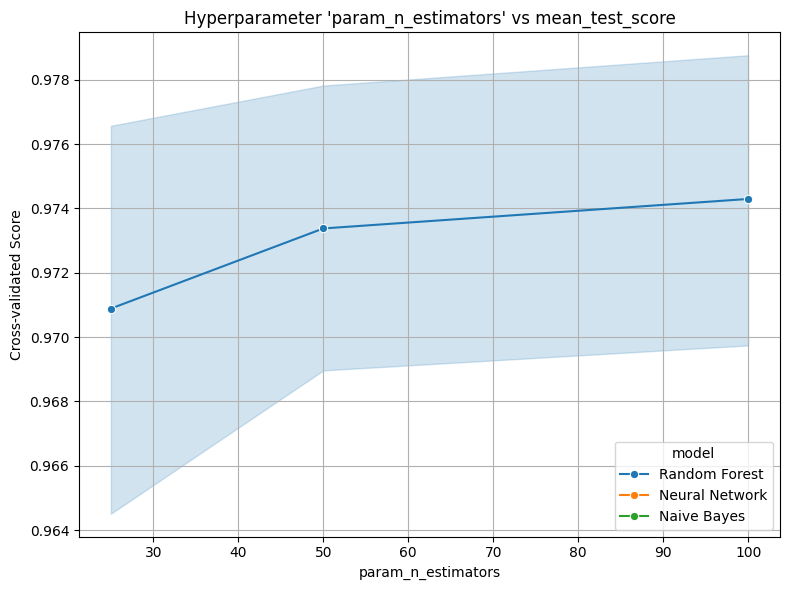

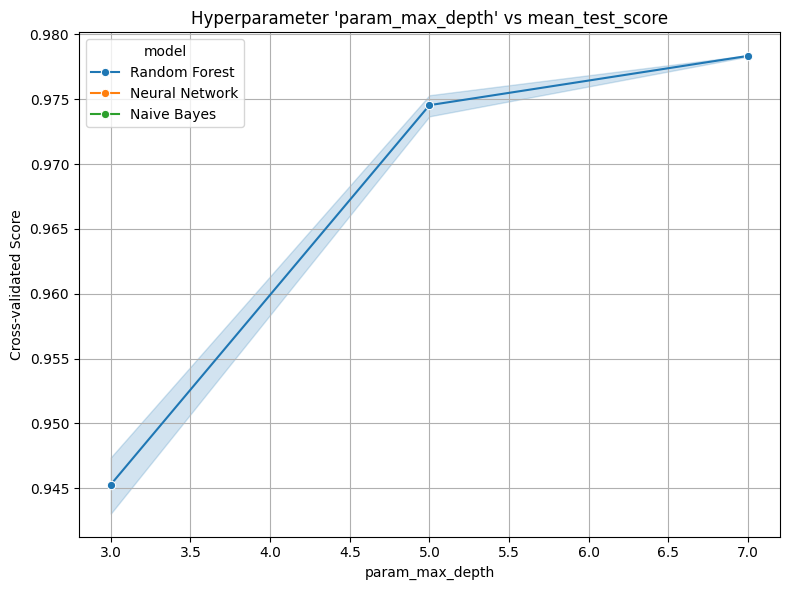

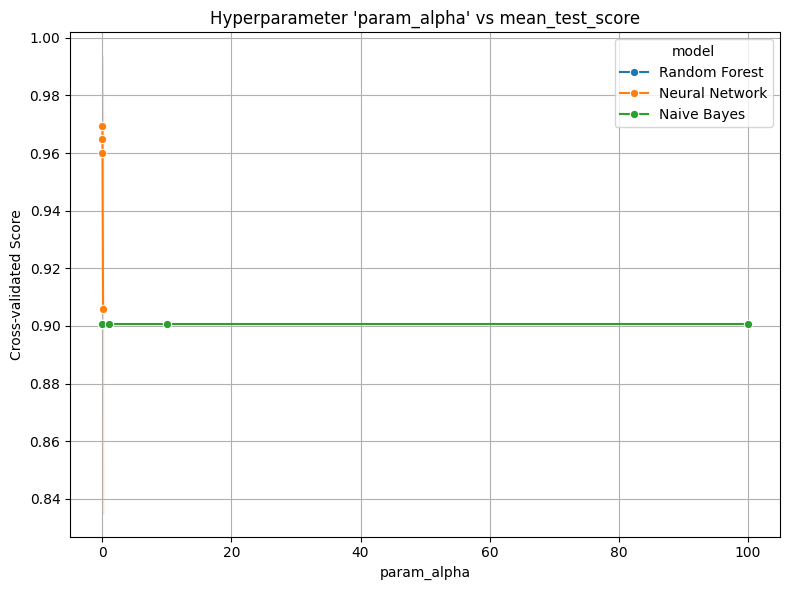

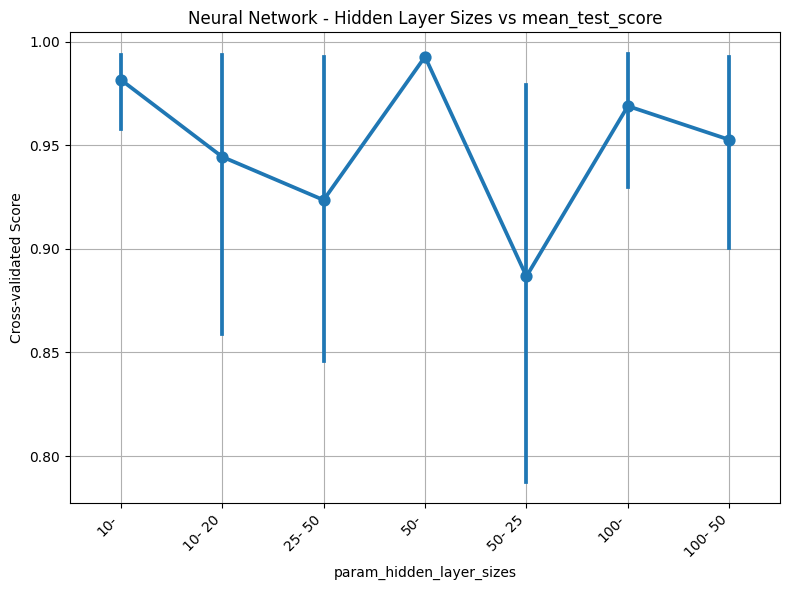

Voting classifier grid search? 
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Voting Classifier - Best parameters: {'weights': [3, 1, 1]}
Voting Classifier - Best score: 0.995304508789765


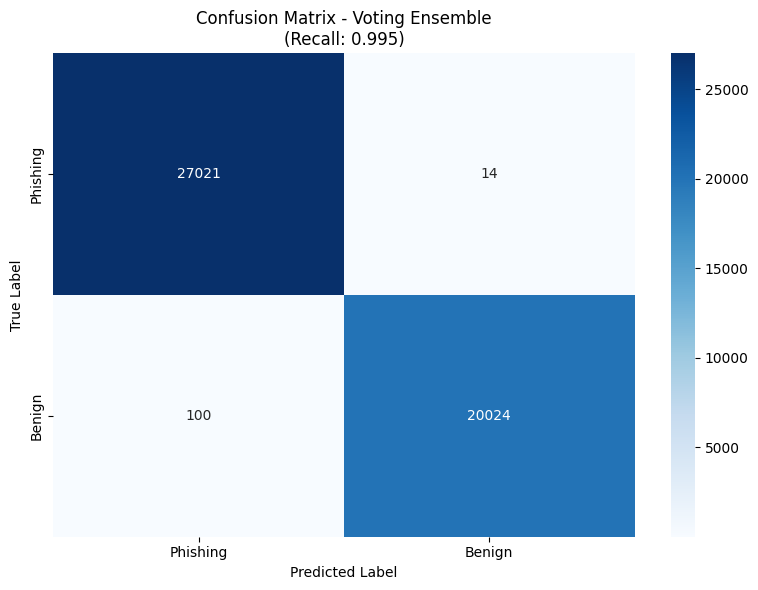

Precision: 0.9993, Recall: 0.9950, F1-Score: 0.9972


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import make_scorer, precision_recall_fscore_support, confusion_matrix
from sklearn.ensemble import VotingClassifier
from sklearn.preprocessing import LabelEncoder

from src.baseline_model import baseline_model
from src.decision_tree_full import decision_tree_with_gridsearch
from src.models import PHISURL_NaiveBayes, PHISURL_NeuralNetwork, PHISURL_RandomForest
from utils import plot_confusion_matrix
from src.input_to_test import preprocess_single_url

DROP_COLS = ["FILENAME", "URL", "Domain", "Title"]

# Custom scoring function
def fn_focused_scorer(y_true, y_pred, fn_weight=5.0, fp_weight=1.0):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    return (fn_weight * recall + fp_weight * specificity) / (fn_weight + fp_weight)

# Generic function to run grid search and return results
def run_gridsearch(model, param_grid, X_train, y_train, X_test, y_test, model_name):
    print(f"Running grid search for {model_name}...")
    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring=make_scorer(fn_focused_scorer),
        cv=5,
        n_jobs=-1,
        verbose=1
    )
    grid.fit(X_train, y_train)

    # Evaluate on test set
    y_pred = grid.predict(X_test)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary')
    print(f"{model_name} - Best params: {grid.best_params_}")
    print(f"{model_name} - CV Best Score: {grid.best_score_:.4f}")
    print(f"{model_name} - Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

    # Save full grid search results
    results_df = pd.DataFrame(grid.cv_results_)
    results_df['model'] = model_name

    return grid.best_estimator_, results_df

# Plotting hyperparameter effects
def plot_hyperparam_results(all_results, param_name, score_name='mean_test_score'):
    plt.figure(figsize=(8,6))
    
    # Create a copy to avoid modifying original data
    plot_data = all_results.copy()
    
    # Special handling for hidden_layer_sizes parameter
    if param_name == 'param_hidden_layer_sizes':
        # Convert tuples to readable strings and filter only Neural Network data
        plot_data = plot_data[plot_data['model'] == 'Neural Network'].copy()
        plot_data[param_name] = plot_data[param_name].apply(
            lambda x: str(x).replace('(', '').replace(')', '').replace(',', '-') if pd.notna(x) else x
        )
        
        # Use pointplot instead of lineplot for categorical x-axis
        sns.pointplot(data=plot_data, x=param_name, y=score_name, marker='o')
        plt.title(f"Neural Network - Hidden Layer Sizes vs {score_name}")
    else:
        # For other parameters, use regular lineplot
        sns.lineplot(data=plot_data, x=param_name, y=score_name, hue='model', marker='o')
        plt.title(f"Hyperparameter '{param_name}' vs {score_name}")
    
    plt.ylabel("Cross-validated Score")
    plt.xlabel(param_name)
    
    # Rotate x-axis labels if they're long
    if param_name == 'param_hidden_layer_sizes':
        plt.xticks(rotation=45, ha='right')
    
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Extract TLD features
def extract_tld_features(df):
    tld_freq = df["TLD"].value_counts(normalize=True)
    df["TLDFrequency"] = df["TLD"].map(tld_freq).fillna(0)
    return df

def main():
    # Load and preprocess dataset
    pure_data_set = pd.read_csv("dataset/PhiUSIIL_Phishing_URL_Dataset.csv")
    pure_data_set = pure_data_set.drop(columns=DROP_COLS)
    pure_data_set["label"] = pure_data_set["label"].map({0: 1, 1: 0})  # Phishing=1, Safe=0

    X = pure_data_set.drop("label", axis=1)
    y = pure_data_set["label"]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Baseline model
    if input("baseline? ") == "y":
        baseline_model(X_train, y_train)

    # Decision tree
    if input("Decision tree? ") == "y":
        decision_tree_with_gridsearch(X_train, y_train)

    # Constrain features
    features = [
        "TLDLength", "URLLength", "IsDomainIP", "NoOfSubDomain", "IsHTTPS",
        "NoOfDegitsInURL", "NoOfEqualsInURL", "NoOfQMarkInURL",
        "NoOfAmpersandInURL", "NoOfOtherSpecialCharsInURL", "DomainLength"
    ]
    X = extract_tld_features(X)
    X_constrained = X[features]
    X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_constrained, y, test_size=0.2, random_state=42)

    # Initialize models
    rf_model = PHISURL_RandomForest()
    nn_model = PHISURL_NeuralNetwork()
    nb_model = PHISURL_NaiveBayes()

    # Run hyperparameter reporting and plotting
    rf_best, nn_best, nb_best, all_results = main_hyperparam_reporting(
        X_train_c, y_train_c, X_test_c, y_test_c, rf_model, nn_model, nb_model
    )

    # Voting Classifier - paste your code here
    best_models = {"rf": rf_best, "nn": nn_best, "nb": nb_best}
    print("Voting classifier grid search? ")
    
    ensemble = VotingClassifier(
        estimators=[
            ("nn", best_models["nn"]),
            ("nb", best_models["nb"]),
            ("rf", best_models["rf"]),
        ],
        voting="soft"
    )

    param_grid = {
        "weights": [
            [1,1,1], [2,1,1], [1,2,1], [1,1,2],
            [3,1,1], [1,3,1], [1,1,3],
            [1,0,0], [0,1,0], [0,0,1]
        ]
    }

    grid = GridSearchCV(
        ensemble,
        param_grid=param_grid,
        scoring=make_scorer(fn_focused_scorer),
        cv=5,
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X_train_c, y_train_c)
    print("Voting Classifier - Best parameters:", grid.best_params_)
    print("Voting Classifier - Best score:", grid.best_score_)

    y_pred = grid.predict(X_test_c)
    plot_confusion_matrix(y_test_c, y_pred, "Voting Ensemble")
    
    precision, recall, f1, _ = precision_recall_fscore_support(y_test_c, y_pred, average="binary")
    print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1-Score: {f1:.4f}")

# Refactored hyperparameter reporting
def main_hyperparam_reporting(X_train, y_train, X_test, y_test, rf_model, nn_model, nb_model):
    rf_param_grid = {
        "n_estimators": [25, 50, 100],
        "max_depth": [3,5,7,None],
        "min_samples_split": [2,5,10],
        "min_samples_leaf": [1,2,4,8]
    }
    
    # Use tuples instead of lists for hidden_layer_sizes
    nn_param_grid = {
        "hidden_layer_sizes": [(10,), (10,20), (25,50), (50,), (50,25), (100,), (100,50)],
        "alpha": [0.0001,0.001,0.01,0.1],
        "learning_rate_init": [0.001,0.01,0.1]
    }
    
    nb_param_grid = {"alpha": [1e-8,1e-6,1e-4,1e-2,1.0,10.0,100.0]}

    rf_best, rf_results = run_gridsearch(rf_model, rf_param_grid, X_train, y_train, X_test, y_test, 'Random Forest')
    nn_best, nn_results = run_gridsearch(nn_model, nn_param_grid, X_train, y_train, X_test, y_test, 'Neural Network')
    nb_best, nb_results = run_gridsearch(nb_model, nb_param_grid, X_train, y_train, X_test, y_test, 'Naive Bayes')

    all_results = pd.concat([rf_results, nn_results, nb_results], ignore_index=True)
    all_results.to_csv("all_model_gridsearch_results.csv", index=False)

    # Plot example hyperparameters - skip hidden_layer_sizes or handle it specially
    plot_hyperparam_results(all_results, 'param_n_estimators')
    plot_hyperparam_results(all_results, 'param_max_depth')
    plot_hyperparam_results(all_results, 'param_alpha')
    
    # Only plot hidden_layer_sizes if we're using the fixed version
    plot_hyperparam_results(all_results, 'param_hidden_layer_sizes')

    return rf_best, nn_best, nb_best, all_results

if __name__ == "__main__":
    main()